# 03 — Modelo de Regresión: Predicción de Días de Entrega

**Tarea:** predecir `dias_entrega` (variable continua)  
**Arquitectura:** Red Feed-Forward con Embeddings (Keras Functional API)  
**Loss:** MAE · **Optimizador:** Adam

In [1]:
import pandas as pd
import numpy as np
import pickle
import matplotlib.pyplot as plt
from pathlib import Path

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

print('TensorFlow:', tf.__version__)

DATA_DIR   = Path('../data/processed')
MODELS_DIR = Path('../models')
OUT_DIR    = Path('../outputs/graficas')

TensorFlow: 2.21.0


## 1. Cargar datos procesados

In [2]:
train = pd.read_csv(DATA_DIR / 'train.csv')
val   = pd.read_csv(DATA_DIR / 'val.csv')
test  = pd.read_csv(DATA_DIR / 'test.csv')

with open(DATA_DIR / 'preprocesadores.pkl', 'rb') as f:
    prep = pickle.load(f)

FEATURES_NUM = prep['features_num']
FEATURES_CAT = prep['features_cat']
CARDS        = prep['cardinalidades']  # cardinalidades para embeddings

print(f'Train: {len(train):,} | Val: {len(val):,} | Test: {len(test):,}')

Train: 76,945 | Val: 9,618 | Test: 9,619


## 2. Preparar inputs para Keras

In [3]:
def preparar_inputs(df):
    """Devuelve lista de arrays: [numericos, cat1, cat2, cat3]."""
    X_num = df[FEATURES_NUM].values.astype('float32')
    X_cat = [df[col].values.astype('int32') for col in FEATURES_CAT]
    return [X_num] + X_cat

X_train = preparar_inputs(train)
y_train = train['dias_entrega'].values.astype('float32')

X_val   = preparar_inputs(val)
y_val   = val['dias_entrega'].values.astype('float32')

X_test  = preparar_inputs(test)
y_test  = test['dias_entrega'].values.astype('float32')

## 3. Arquitectura de la red

In [4]:
def construir_modelo_regresion(cards, n_num):
    """
    Arquitectura Feed-Forward con Embeddings para datos tabulares.
    - cards: dict {nombre_col: cardinalidad}
    - n_num: número de features numéricas
    """
    # --- Entrada numérica ---
    inp_num = keras.Input(shape=(n_num,), name='input_numerico')

    # --- Entradas categóricas con Embeddings ---
    emb_outputs = []
    emb_inputs  = []
    for col, card in cards.items():
        dim = min(50, (card // 2) + 1)  # dimensión del embedding
        inp = keras.Input(shape=(1,), name=f'input_{col}', dtype='int32')
        emb = layers.Embedding(input_dim=card, output_dim=dim, name=f'emb_{col}')(inp)
        emb = layers.Flatten()(emb)
        emb_inputs.append(inp)
        emb_outputs.append(emb)

    # --- Concatenar todo ---
    x = layers.Concatenate()([inp_num] + emb_outputs)

    # --- Bloques densos (pirámide invertida) ---
    for unidades in [256, 128, 64]:
        x = layers.Dense(unidades, activation='relu')(x)
        x = layers.BatchNormalization()(x)
        x = layers.Dropout(0.3 if unidades == 256 else 0.2)(x)

    # --- Salida regresión ---
    salida = layers.Dense(1, activation='linear', name='dias_entrega')(x)

    modelo = keras.Model(
        inputs=[inp_num] + emb_inputs,
        outputs=salida,
        name='modelo_regresion'
    )
    return modelo

modelo = construir_modelo_regresion(CARDS, n_num=len(FEATURES_NUM))
modelo.summary()

Model: "modelo_regresion"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_categoria_pr… │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_customer_sta… │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_seller_state  │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ emb_categoria_prod… │ (None, 1, 37)     │      2,664 │ input_categoria_… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ emb_customer_state  │ (None, 1, 14)     │        378 │ input_customer_s… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ emb_seller_state    │ (None, 1, 12)     │        264 │ input_seller_sta… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_numerico      │ (None, 8)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 37)        │          0 │ emb_categoria_pr… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_1 (Flatten) │ (None, 14)        │          0 │ emb_customer_sta… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_2 (Flatten) │ (None, 12)        │          0 │ emb_seller_state… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 71)        │          0 │ input_numerico[0… │
│ (Concatenate)       │                   │            │ flatten[0][0],    │
│                     │                   │            │ flatten_1[0][0],  │
│                     │                   │            │ flatten_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 256)       │     18,432 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 256)       │      1,024 │ dense[0][0]       │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 256)       │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 128)       │     32,896 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128)       │        512 │ dense_1[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 128)       │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 64)        │      8,256 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64)        │        256 │ dense_2[0][0]   

 Total params: 64,747 (252.92 KB)

 Trainable params: 63,851 (249.42 KB)

 Non-trainable params: 896 (3.50 KB)

## 4. Compilar y entrenar

In [5]:
modelo.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='mae',
    metrics=['mae']
)

callbacks = [
    keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=10,
        restore_best_weights=True, verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.5,
        patience=5, verbose=1
    )
]

historia = modelo.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=256,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/100
301/301 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - loss: 9.1657 - mae: 9.1657 - val_loss: 3.6505 - val_mae: 3.6505 - learning_rate: 0.0010
Epoch 2/100
301/301 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 5.2680 - mae: 5.2680 - val_loss: 3.6062 - val_mae: 3.6062 - learning_rate: 0.0010
Epoch 3/100
301/301 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 5.1339 - mae: 5.1339 - val_loss: 3.5521 - val_mae: 3.5521 - learning_rate: 0.0010
Epoch 4/100
301/301 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 5.0650 - mae: 5.0650 - val_loss: 3.5309 - val_mae: 3.5309 - learning_rate: 0.0010
Epoch 5/100
301/301 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 5.0331 - mae: 5.0331 - val_loss: 3.5502 - val_mae: 3.5502 - learning_rate: 0.0010
Epoch 6/100
301/301 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 4.9948 - mae: 4.9948 - val_loss: 3.6013 - val_mae: 3.6013 - learning_rate: 0.0010
Epoch 7/100
301/301 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 4.9701 - mae: 4.9701 - val_loss: 3.5310 - val_mae: 3.5310 - learning_rate: 0.0010

## 5. Curva de aprendizaje

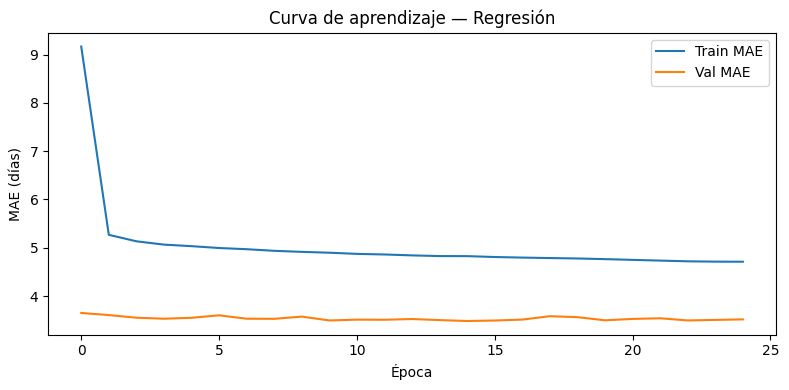

In [6]:
plt.figure(figsize=(8, 4))
plt.plot(historia.history['loss'],     label='Train MAE')
plt.plot(historia.history['val_loss'], label='Val MAE')
plt.title('Curva de aprendizaje — Regresión')
plt.xlabel('Época')
plt.ylabel('MAE (días)')
plt.legend()
plt.tight_layout()
plt.savefig(OUT_DIR / 'curva_regresion.png', dpi=100)
plt.show()

## 6. Métricas en test

In [7]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

y_pred = modelo.predict(X_test).flatten()

mae  = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2   = r2_score(y_test, y_pred)

print(f'MAE:  {mae:.2f} días')
print(f'RMSE: {rmse:.2f} días')
print(f'R²:   {r2:.4f}')

301/301 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
MAE:  3.26 días
RMSE: 4.39 días
R²:   0.1546


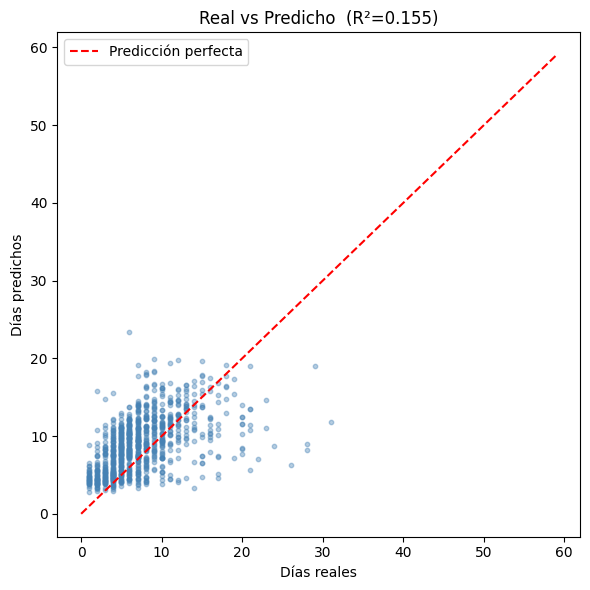

In [8]:
# Scatter: real vs predicho (muestra aleatoria de 1000)
idx = np.random.choice(len(y_test), 1000, replace=False)

plt.figure(figsize=(6, 6))
plt.scatter(y_test[idx], y_pred[idx], alpha=0.4, s=10, color='steelblue')
lim = max(y_test.max(), y_pred.max())
plt.plot([0, lim], [0, lim], 'r--', label='Predicción perfecta')
plt.xlabel('Días reales')
plt.ylabel('Días predichos')
plt.title(f'Real vs Predicho  (R²={r2:.3f})')
plt.legend()
plt.tight_layout()
plt.savefig(OUT_DIR / 'scatter_regresion.png', dpi=100)
plt.show()

## 7. Guardar modelo

In [9]:
modelo.save(MODELS_DIR / 'modelo_regresion.keras')
print('Modelo guardado en models/modelo_regresion.keras')

Modelo guardado en models/modelo_regresion.keras
